In [1]:
import sys
from IPython.display import display, Javascript

def restart_kernel():
    """Restart the Jupyter Notebook kernel to reflect changes in modules and packages."""
    display(Javascript("Jupyter.notebook.kernel.restart()"))
    print("Kernel is restarting...")

restart_kernel()

import numpy as np
import torch
import tensorly as tl
from tensorly.decomposition import parafac
import sparse
import pickle
import os
import numpy.random as rn
import scipy.stats as st
from tensorly.cp_tensor import CPTensor

from bptf import BPTF as BPTF
import bptf


<IPython.core.display.Javascript object>

Kernel is restarting...


# Helper functions

In [2]:
def generate(shp=(30, 30, 20, 10), K=5, alpha=0.1, beta=0.1):
    """Generate a count tensor from the BPTF model.

    PARAMS:
    shp -- (tuple) shape of the generated count tensor
    K -- (int) number of latent components
    alpha -- (float) shape parameter of gamma prior over factors
    beta -- (float) rate parameter of gamma prior over factors

    RETURNS:
    Mu -- (np.ndarray) true Poisson rates
    Y -- (np.ndarray) generated count tensor
    """
    Theta_DK_M = [rn.gamma(alpha, 1./beta, size=(D, K)) for D in shp]
    Mu = tl.cp_to_tensor(CPTensor((None, Theta_DK_M)))
    assert Mu.shape == shp
    Y = rn.poisson(Mu)
    return Mu, Y

def compare_support(X, Y, thr=0.05):
    """
    Compare the binary ‘non-zero’ supports of two fitted tensors.
    Parameters
    ----------
    X, Y : torch.Tensor  (same shape)
        Reconstructions you want to compare.
    thr : float
        Entries ≤ thr are treated as structural zeros.
    Returns
    -------
    dict with TP, FP, FN counts + agreement metrics.
    """
    Sx = X > thr                       # support of your fit
    Sy = Y > thr                       # support of Aaron’s fit

    tp = (Sx &  Sy).sum().item()       # both predict non-zero
    fp = (Sx & ~Sy).sum().item()       # you only
    fn = (~Sx & Sy).sum().item()       # Aaron only
    union = (Sx | Sy).sum().item()

    precision = tp / (tp + fp) if tp + fp else 1.0
    recall    = tp / (tp + fn) if tp + fn else 1.0
    f1        = 2*precision*recall / (precision + recall) if precision+recall else 0.0
    jaccard   = tp / union if union else 1.0

    return dict(tp=tp, fp=fp, fn=fn,
                precision=precision, recall=recall,
                f1=f1, jaccard=jaccard)

# Generate data

In [3]:
use_existing_data = True

rn.seed(0)

if use_existing_data:
    assert os.path.exists('sptensor.pkl'), 'No such file.'
    with open('sptensor.pkl', 'rb') as f:
        data = pickle.load(f)
    data = data[:, :, :, :12, :]
    data = sparse.COO(data)
    print(f'Percentage of cells that are non-zero: {data.data.shape[0] / np.prod(np.array(list(data.shape))) * 100: .3}%')
else:
    data = generate(shp=(200, 200, 20, 12, 3), K=10)[1]
    data = sparse.COO(data)

Percentage of cells that are non-zero:  0.713%


# Fit with BPTF

In [4]:
n_components = 50
max_iter = 500
device = 'cuda'
tol = 1e-6

mask = np.zeros(data.shape)
# april of GDELT is set to missing
mask[:, :, :, 3, 1] = 1

# diagonals are set to missing
mask[np.eye(mask.shape[0]).astype(bool)] = 1
mask = sparse.COO(mask.astype(np.int64))

# BPTF_model_withmask = BPTF(data_shape=data.shape, n_components=n_components)
# BPTF_model_withmask.fit(data, mask = mask, max_iter = max_iter, verbose=False, missing_val=1, tol=tol)

BPTF_model_nomask = BPTF(data_shape=data.shape, n_components=n_components)
BPTF_model_nomask.fit(data, mask = None, max_iter = max_iter, verbose=False, missing_val=1, tol=tol)


  0%|                                                                                                      | 0/500 [00:00<?, ?it/s]

Are the shape parameters positive? True
Are the rate parameters positive? True
Are the shape parameters finite? True
Are the rate parameters finite? True
[mode 0]  min uttkrp_DK = 1.730e+05
[mode 0]  min new rate = 1.730e+05   negatives = 0
Is G_DK_M finite before updating? True
Are there NaNs in G_DK_M after updating cache? False
Is G_DK_M finite after updating? True


Are the shape parameters positive? True
Are the rate parameters positive? True
Are the shape parameters finite? True
Are the rate parameters finite? True
[mode 1]  min uttkrp_DK = 3.886e+02
[mode 1]  min new rate = 3.887e+02   negatives = 0
Is G_DK_M finite before updating? True
Are there NaNs in G_DK_M after updating cache? False
Is G_DK_M finite after updating? True


Are the shape parameters positive? True
Are the rate parameters positive? True
Are the shape parameters finite? True
Are the rate parameters finite? True
[mode 2]  min uttkrp_DK = 4.234e+03
[mode 2]  min new rate = 4.234e+03   negatives = 0
Is G_DK_M finite before updating? True
Are there NaNs in G_DK_M after updating cache? False
Is G_DK_M finite after updating? True


Are the shape parameters positive? True
Are the rate parameters positive? True
Are the shape parameters finite? True
Are the rate parameters finite? True
[mode 3]  min uttkrp_DK = 5.421e+03
[mode 3]  min new rate = 5.421e+03   negatives = 0
Is G_DK_M finite before updating? True
Are there NaNs in G_DK_M after updating cache? False
Is G_DK_M finite after updating? True


...

Are the shape parameters positive? True
Are the rate parameters positive? True
Are the shape parameters finite? True
Are the rate parameters finite? True
[mode 2]  min uttkrp_DK = 2.026e+03
[mode 2]  min new rate = 2.027e+03   negatives = 0
Is G_DK_M finite before updating? True
Are there NaNs in G_DK_M after updating cache? False
Is G_DK_M finite after updating? True


Are the shape parameters positive? True
Are the rate parameters positive? True
Are the shape parameters finite? True
Are the rate parameters finite? True
[mode 3]  min uttkrp_DK = 3.313e+03
[mode 3]  min new rate = 3.314e+03   negatives = 0
Is G_DK_M finite before updating? True
Are there NaNs in G_DK_M after updating cache? False
Is G_DK_M finite after updating? True


Are the shape parameters positive? True
Are the rate parameters positive? True
Are the shape parameters finite? True
Are the rate parameters finite? True
[mode 4]  min uttkrp_DK = 1.305e+04
[mode 4]  min new rate = 1.305e+04   negatives = 0
Is G_DK_M finite before updating? True
Are there NaNs in G_DK_M after updating cache? False
Is G_DK_M finite after updating? True



 35%|████████████████████████████████▏                                                           | 175/500 [11:16<20:55,  3.86s/it]

BPTF(data_shape=(280, 280, 20, 12, 3), n_components=50)

# Fit with own BPTF_torch

In [5]:
from own_implementation import BPTF as BPTF_torch


  0%|                                                                                                      | 0/500 [00:00<?, ?it/s]


ELBO =  8408674.495, change =  1.0, time taken =  0.287, mem alloc =  0.986GB:   0%|                       | 0/500 [00:00<?, ?it/s]


ELBO =  8408674.495, change =  1.0, time taken =  0.287, mem alloc =  0.986GB:   0%|               | 1/500 [00:00<02:23,  3.48it/s]


ELBO =  8689891.073, change =  0.0334, time taken =  0.284, mem alloc =  0.986GB:   0%|            | 1/500 [00:00<02:23,  3.48it/s]


ELBO =  8689891.073, change =  0.0334, time taken =  0.284, mem alloc =  0.986GB:   0%|            | 2/500 [00:00<02:22,  3.49it/s]

...


ELBO =  19235716.482, change =  2.16e-06, time taken =  0.285, mem alloc =  0.986GB:  36%|██▌    | 179/500 [00:51<01:32,  3.49it/s]


ELBO =  19235733.504, change =  8.85e-07, time taken =  0.285, mem alloc =  0.986GB:  36%|██▌    | 179/500 [00:51<01:32,  3.49it/s]


Change is small enough, early break:  36%|███████████████████▋                                   | 179/500 [00:51<01:32,  3.49it/s]


Change is small enough, early break:  36%|███████████████████▋                                   | 179/500 [00:51<01:32,  3.47it/s]

Number of negative deltas: 0
When do they occur? []
what is their magnitude? []


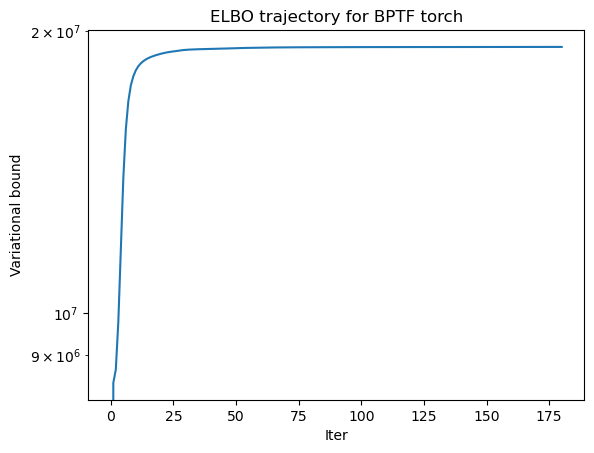

BPTF(alpha=tensor([0.1000], device='cuda:0'),
     data_shape=torch.Size([280, 280, 20, 12, 3]), device='cuda',
     n_components=50)

In [6]:
mask = (1 - mask.todense()).astype(np.int64)
mask = torch.tensor(mask, dtype=torch.float64, device=device)

data = torch.tensor(data.todense(), dtype = torch.float64, device=device)
BPTF_model_torch_nomask = BPTF_torch(data_shape=data.shape, n_components=n_components, device=device)
BPTF_model_torch_nomask.fit(data, mask = None, max_iter = max_iter, verbose=True, tol=tol)

# BPTF_model_torch_withmask = BPTF_torch(data_shape=data.shape, n_components=n_components, device=device)
# BPTF_model_torch_withmask.fit(data, mask = mask, max_iter = max_iter, verbose=True, tol=tol)

# Check similarity

## No mask

Frobenius norm relative difference with only unmasked data: 0.37383155777746996
correlation index for geom mean 0.1439533237603778
correlation index for arithmetic mean 0.1439465143706791
Proportion of elements with difference greater than 0.05 = 0.0434422654478458
Fro norm of BPTF factors = 2.4144245962490487
Fro norm of BPTF factors = 906.9569803771019
Fro norm of BPTF factors = 66.46169391490146
Fro norm of BPTF factors = 27.678864079149164
Fro norm of BPTF factors = 18.634672972645376
Fro norm of BPTF_torch factors = 2.3356219555064883
Fro norm of BPTF_torch factors = 901.1179033238803
Fro norm of BPTF_torch factors = 67.2232843402316
Fro norm of BPTF_torch factors = 27.236132347629
Fro norm of BPTF_torch factors = 18.778109143132777
mode 0: ref mean=0.003, std=0.020; torch mean=0.003, std=0.020
mode 1: ref mean=1.007, std=7.599; torch mean=1.006, std=7.549
mode 2: ref mean=1.023, std=1.837; torch mean=1.024, std=1.864
mode 3: ref mean=0.980, std=0.562; torch mean=0.974, std=0.536


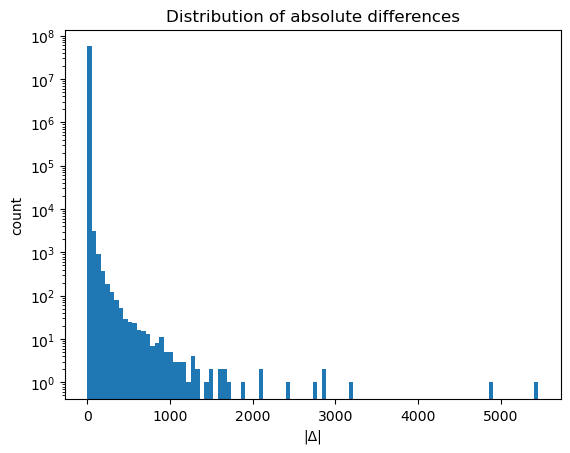

tensor([201136, 194968, 201104, 213870, 226162, 229168, 197020, 200872, 199079,
        206484, 201802, 180564], device='cuda:0')
{'tp': 2963274, 'fp': 535551, 'fn': 542553, 'precision': 0.8469340421427194, 'recall': 0.845242506261718, 'f1': 0.8460874287544907, 'jaccard': 0.7332335653828966}
(array([121, 203, 121, 203, 121, 121, 121, 203, 126, 121, 121, 203, 121,
       121, 203, 121, 121, 121, 121, 261]), array([121, 203, 121, 203, 203, 203, 138, 121, 126, 121, 203, 203, 203,
       203, 121, 203, 138, 138, 203, 261]), array([18, 18, 18, 18, 18,  7, 18,  3,  3, 18, 18, 18, 18,  7, 10, 18,  7,
       18,  7,  3]), array([ 9,  9, 10, 10,  4,  9,  9,  9,  6, 11,  2, 11,  1, 10,  9,  3,  4,
       10,  4,  3]), array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]))


/tmp/ipykernel_622482/794966711.py:57: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  print(np.unravel_index(idx.cpu(), diff.shape))


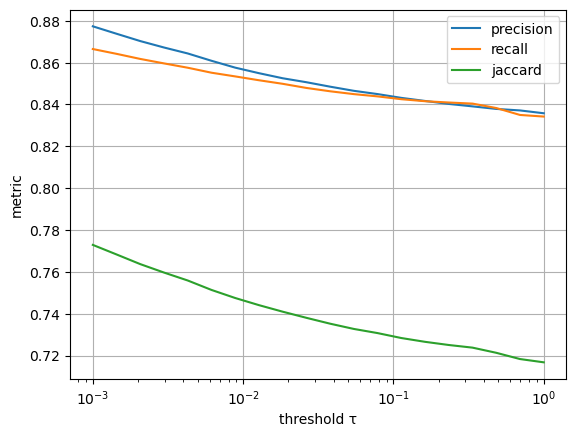

In [7]:
coords = (data != 0).nonzero(as_tuple=False)

BPTF_G_DK_M = [torch.tensor(factor_matrix, dtype=torch.float64, device=device) for factor_matrix in BPTF_model_nomask.G_DK_M]
BPTF_E_DK_M = [torch.tensor(factor_matrix, dtype=torch.float64, device=device) for factor_matrix in BPTF_model_nomask.E_DK_M]
data_hat_torch = BPTF_model_torch_nomask.reconstruct(style='geometric')
data_hat = tl.cp_tensor.cp_to_tensor((None, BPTF_G_DK_M))
if use_existing_data:
    data_hat_torch = data_hat_torch[tuple(coords.T)]
    data_hat = data_hat[tuple(coords.T)]
    fro_norm_rel_diff = torch.norm(data_hat_torch - data_hat, 'fro') / torch.norm(data_hat, 'fro')
    print(f'Frobenius norm relative difference with only unmasked data: {fro_norm_rel_diff}')
else:
    fro_norm_rel_diff = torch.norm(data_hat_torch - data_hat, 'fro') / torch.norm(data_hat, 'fro')
    print(f'Frobenius norm relative difference: {fro_norm_rel_diff}')

print(f'correlation index for geom mean {tl.metrics.similarity.correlation_index(BPTF_G_DK_M, BPTF_model_torch_nomask.G_DK_M)}')
print(f'correlation index for arithmetic mean {tl.metrics.similarity.correlation_index(BPTF_E_DK_M, BPTF_model_torch_nomask.E_DK_M)}')

threshold = 0.05
diff = torch.abs(BPTF_model_torch_nomask.reconstruct(style='geometric') - tl.cp_tensor.cp_to_tensor((None, BPTF_G_DK_M)))
prop_exceed = (diff > threshold).sum().item() / diff.numel()
print(f'Proportion of elements with difference greater than {threshold} = {prop_exceed}')

# BPTF
for m in range(len(BPTF_G_DK_M)):
    print(f'Fro norm of BPTF factors = {torch.norm(BPTF_G_DK_M[m])}')

# BPTF torch
for m in range(len(BPTF_G_DK_M)):
    print(f'Fro norm of BPTF_torch factors = {torch.norm(BPTF_model_torch_nomask.G_DK_M[m])}')

for m, (A_ref, A_torch) in enumerate(zip(BPTF_G_DK_M, BPTF_model_torch_nomask.G_DK_M)):
    print(f"mode {m}: ref mean={A_ref.mean():.3f}, std={A_ref.std():.3f}; "
          f"torch mean={A_torch.mean():.3f}, std={A_torch.std():.3f}")

# 1) How big are the large errors?
big = diff[diff > 0.05]
print(big.mean(), big.median(), big.max())

# 2) Histogram of the absolute differences
import matplotlib.pyplot as plt
plt.hist(diff.flatten().cpu().numpy(), bins=100, log=True)
plt.xlabel('|Δ|'); plt.ylabel('count'); plt.title('Distribution of absolute differences')
plt.show()

# 3) Where do they occur?  Example for mode-4 time slices
exceed_mask = (diff > 0.05)
time_exceed = exceed_mask.view(data.shape).sum(dim=(0,1,2,4))
print(time_exceed)  # counts per month

# Check whether the predictions for nnz locations are the same
nnz_prediction_stats = compare_support(BPTF_model_torch_nomask.reconstruct(style='geometric'), tl.cp_tensor.cp_to_tensor((None, BPTF_G_DK_M)), thr=0.05)
print(nnz_prediction_stats)

diff = (BPTF_model_torch_nomask.reconstruct(style='geometric') - tl.cp_tensor.cp_to_tensor((None, BPTF_G_DK_M))).abs()
idx   = diff.flatten().topk(20).indices
print(np.unravel_index(idx.cpu(), diff.shape))

thrs = np.logspace(-3, 0, 20)          # 0.001 … 1
stats = [compare_support(BPTF_model_torch_nomask.reconstruct(style='geometric'), tl.cp_tensor.cp_to_tensor((None, BPTF_G_DK_M)), thr=t) for t in thrs]

prec = [s['precision'] for s in stats]
rec  = [s['recall']    for s in stats]
jacc = [s['jaccard']   for s in stats]

plt.semilogx(thrs, prec, label='precision')
plt.semilogx(thrs, rec,  label='recall')
plt.semilogx(thrs, jacc, label='jaccard')
plt.xlabel('threshold τ'); plt.ylabel('metric'); plt.legend(); plt.grid(True)
plt.show()

In [8]:
from scipy.optimize import linear_sum_assignment

def match_components(factors_ref, factors_own):
    N = len(factors_ref)
    R = factors_ref[0].shape[1]
    # build per-mode absolute correlations
    S_modes = []
    for A, B in zip(factors_ref, factors_own):
        A_n = (A / A.norm(dim=0, keepdim=True))
        B_n = (B / B.norm(dim=0, keepdim=True))
        S_modes.append((A_n.T @ B_n).abs().cpu().numpy())
    S = sum(S_modes) / N     # average similarity matrix
    row_ind, col_ind = linear_sum_assignment(1 - S)
    return row_ind, col_ind

# reference and your torch factors
f_ref   = BPTF_G_DK_M
f_own   = BPTF_model_torch_nomask.G_DK_M

row_ind, col_ind = match_components(f_ref, f_own)
# build permuted list of your factors:
# Now permute the *columns* in each factor:
f_own_aligned = [
    B[:, col_ind]    # re-order columns by the matching col_ind
    for B in f_own
]

# Recompute reconstructions
Y_ref        = tl.cp_tensor.cp_to_tensor((None, f_ref))
Y_own_aligned = tl.cp_tensor.cp_to_tensor((None, f_own_aligned))

fro_rel = (Y_ref - Y_own_aligned).norm() / Y_ref.norm()
corr    = tl.metrics.similarity.correlation_index(f_ref, f_own_aligned)

print(f"Post-match rel. Fro error: {fro_rel:.4f}")
print(f"Post-match corr index: {corr:.4f}")

Post-match rel. Fro error: 0.3766
Post-match corr index: 0.1440


In [9]:
import pandas as pd

# Replace these with your actual objects
orig = BPTF_model_nomask        # Aaron’s reference
tch  = BPTF_model_torch_nomask  # Your PyTorch version
n_modes = len(orig.shp_DK_M)

rows = []
for m in range(n_modes):
    shp_ref, shp_tch = orig.shp_DK_M[m],       tch.shp_DK_M[m].cpu().numpy()
    rte_ref, rte_tch = orig.rte_DK_M[m],       tch.rte_DK_M[m].cpu().numpy()
    rows.append({
        "mode": m,
        "mean|Δshape|": np.abs(shp_ref - shp_tch).mean(),
        "max|Δshape|":  np.abs(shp_ref - shp_tch).max(),
        "mean|Δrate|":  np.abs(rte_ref - rte_tch).mean(),
        "max|Δrate|":   np.abs(rte_ref - rte_tch).max(),
    })

df = pd.DataFrame(rows).set_index("mode")
print(df)

      mean|Δshape|    max|Δshape|    mean|Δrate|     max|Δrate|
mode                                                           
0       993.123728  176978.420702  123936.393217  479399.299481
1      1000.776590  187890.127322     301.555829    1247.855396
2      7085.018521  256038.443311    3946.715798   15941.541575
3     11299.427167   80904.722805    6931.710807   25231.141382
4     42185.955907  417435.619654   30630.784600  111582.947353


from plot_utility_functions import plot_all_components


## With mask

In [10]:
# BPTF_G_DK_M = [torch.tensor(factor_matrix, dtype=torch.float64, device=device) for factor_matrix in BPTF_model_withmask.G_DK_M]
# fro_norm_rel_diff = torch.norm(BPTF_model_torch_withmask.reconstruct(style='geometric') - tl.cp_tensor.cp_to_tensor((None, BPTF_G_DK_M)), 'fro') / torch.norm(tl.cp_tensor.cp_to_tensor((None, BPTF_G_DK_M)), 'fro')
# print(f'Frobenius norm relative difference: {fro_norm_rel_diff}')

# threshold = 0.05
# diff = torch.abs(BPTF_model_torch_withmask.reconstruct(style='geometric') - tl.cp_tensor.cp_to_tensor((None, BPTF_G_DK_M)))
# prop_exceed = (diff > threshold).sum().item() / diff.numel()
# print(f'Proportion of elements with difference greater than {threshold} = {prop_exceed}')

# # 1) How big are the large errors?
# big = diff[diff > 0.05]
# print(big.mean(), big.median(), big.max())

# # 2) Histogram of the absolute differences
# import matplotlib.pyplot as plt
# plt.hist(diff.flatten().cpu().numpy(), bins=100, log=True)
# plt.xlabel('|Δ|'); plt.ylabel('count'); plt.title('Distribution of absolute differences')

# # 3) Where do they occur?  Example for mode-4 time slices
# exceed_mask = (diff > 0.05)
# time_exceed = exceed_mask.view(data.shape).sum(dim=(0,1,2,4))
# print(time_exceed)  # counts per month